## Geomagnetic Rigidity Cut-off Using Paleomagnetic field Data

Install and use OTSOpy library for trajectory tracking and computing the cut-off rigidity

## OTSO - Open-source geomagneToSphere prOpagation tool

It is used to calculate the rigidity cut-off values by solving relativistic equation of motion (incorporating Lorentz factor $\gamma$) and the Lorentz force equation.
$$
\frac{d^2x}{dt^2} = \frac{q}{\gamma m_0}(B_z\frac{dy}{dt}-B_y\frac{dz}{dt}) \\ \, \\
\frac{d^2y}{dt^2} = \frac{q}{\gamma m_0}(B_x\frac{dz}{dt}-B_z\frac{dx}{dt}) \\ \, \\
\frac{d^2z}{dt^2} = \frac{q}{\gamma m_0}(B_y\frac{dx}{dt}-B_x\frac{dy}{dt}) \\ \, \\
\mathbb{F}=q\mathbb{E}+q(v\times\mathbb{B}) \\ \, \\\text{ (Here, E is negligible due to the high electrical conductivity of the region)}
$$
where, 
$$
\gamma = \sqrt{\frac{1}{1-(\frac{v}{c})^2}}
$$

The rigidity, $P$ is calculated using --
$$
P = \frac{pc}{Ze}
$$
where, $p$: Cosmic Ray's momentum,
$c$: the speed of light,
$Z$: atomic number of the particle,
$e$: elemental charge

- OTSO utilizes the backward tracing method such that it starts from -
    1. Launching particle from atmosphere
    2. Reverse the velocity
    3. Trace through geomagnetic field
    4. Determine the allowed and forbidden rigidity.

Allowed Rigidity Cut-off: The particles with sufficient momentum per unit charge to penetrate through a certain rigidity layer in the magnetosphere.

Forbidden Rigidity Cut-off: The particles do not have required momentum to pass though a specific region or layer in the magnetosphere, such that these particles cannot be found in that layer of the magnetosphere.

Penumbral Region: Some particle trajectories arriving from directions above the Earth's horizon are blocked by the Earth (including some from zenith angle). These results in a shadow or penumbral region containing bands of forbidden and allowed trajectories at rigidities above the magnetic cut-off rigidity. The effective cut-off rigidity $R_C$ is defined such that it lies in the penumbral region between the upper $(R_U)$ -- above which all trajectories are allowed -- and lower $(R_L)$ -- below which all particle trajectories are shielded -- vertical cut-off rigidities.

Python Library Source Code Credits: [OTSOpy](https://github.com/NLarsen15/OTSOpy)

In [5]:
# !pip3 install OTSO

In [6]:
from OTSO import cutoff
import matplotlib.pyplot as plt

stations = [
    "OULU", "ROME", "ATHN", "CALG",
    "THUL", "APTY", "IRKT"
]

results, _ = cutoff(
    Stations=stations,
    computation_params={"corenum": 1},
    datetime_params={"year": 2014, "month": 1, "day": 1, "hour": 0}
)
print(results.columns)


OTSO Cutoff Computation Started


OTSO Running: 100%|██████████| 1/1 [00:26<00:00, 26.78s/ batch]


OTSO Cutoff Computation Complete
Whole Program Took: 26.797 seconds
Index(['APTY', 'ATHN', 'CALG', 'IRKT', 'OULU', 'ROME', 'THUL'], dtype='str')


In [7]:
print(results.index)
print(results.head())

Index(['Ru', 'Rc', 'Rl'], dtype='str')
    APTY  ATHN  CALG  IRKT  OULU  ROME  THUL
Ru  0.48  8.89  1.17  3.45  0.68  6.36   0.0
Rc  0.48  8.47  1.10  3.13  0.67  6.10   0.0
Rl  0.48  7.51  1.04  2.82  0.61  5.50   0.0


In [8]:
# Extract values
Rc = results.loc["Rc"]
print(Rc)

APTY    0.48
ATHN    8.47
CALG    1.10
IRKT    3.13
OULU    0.67
ROME    6.10
THUL    0.00
Name: Rc, dtype: float64


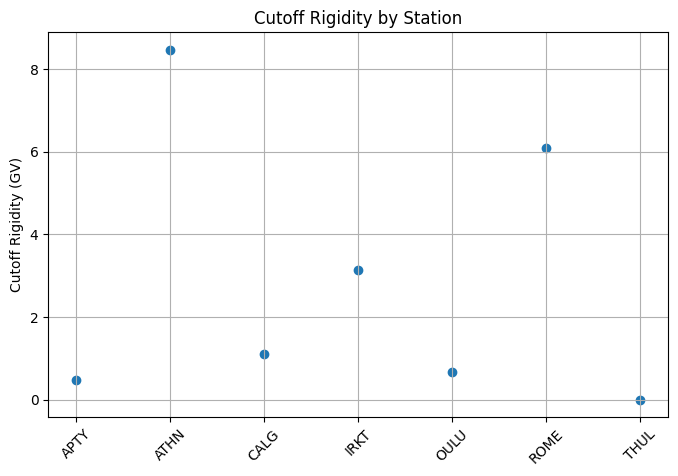

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(Rc.index, Rc.values)

plt.ylabel("Cutoff Rigidity (GV)")
plt.title("Cutoff Rigidity by Station")
plt.xticks(rotation=45)
plt.grid()

plt.show()

In [10]:
cutoff_results = cutoff(
    Stations=stations,
    computation_params={"corenum": 1},
    datetime_params={"year": 2000, "month": 1, "day": 1, "hour": 0}
)

results = cutoff_results[0]
asym_results = cutoff_results[1]


OTSO Cutoff Computation Started


OTSO Running: 100%|██████████| 1/1 [00:30<00:00, 30.67s/ batch]


OTSO Cutoff Computation Complete
Whole Program Took: 30.668 seconds


In [11]:
print(results)

    APTY  ATHN  CALG  IRKT  OULU  ROME  THUL
Ru  0.52  8.98  1.11  3.60  0.72  6.35   0.0
Rc  0.52  8.68  1.03  3.30  0.68  6.09   0.0
Rl  0.52  8.58  1.00  2.92  0.59  5.62   0.0


In [12]:
print(asym_results)


Date of OTSO computation: 2026-03-21
Total computation time: 30.668 seconds

Cutoff Computed: Vertical Cutoff Rigidity

Rigidity Scan:
Rigidity Scan Used

Integration Method:
Boris Method

Input Variables:

Data Used: User Inputted Data Used

Simulation Date: 01/01/2000, 00:00:00

Max Time Step [% of gyrofrequency]: 15.0
Total Beta Error Check Applied: Yes
Adaptive Step Size Used
Beta Error Tolerance: 0.001%

Minimum Altitude: 20km
Max Distance: 100Re
Max Time: 0s
Max Steps: 0.0

Start Altitude = 20km 
Zenith = 0
Azimuth = 0

Kp = 0
IOPT = 1

Solar Wind Speed [km/s]:
Vx = 500
Vy = 0
Vz = 0

IMF [nT]:
Bx = 0
By = 5
Bz = 5

By Average (30mins) = 0
Bz Average (30mins) = 0

Density = 1 cm^-3
Pdyn = 0 nPa

Dst = 0 nT

G1 = 0
G2 = 0
G3 = 0

W1 = 0
W2 = 0
W3 = 0
W4 = 0
W5 = 0
W6 = 0

N = 0
B = 0

SYM-H = 0

Atomic Number = 1

Particle Type = anti-particle

Magnetic Field Models:
Internal Model = IGRF
External Model = Tsyganenko 89c

Magnetopause Model = Kobel Model

Boberg Extension Applied:

In [13]:
from OTSO import flight
import numpy as np
import datetime

latitudes = np.arange(-90, 95, 5)
longitudes = np.arange(-180,190,10)
altitudes = np.arange(30,100,20)

lat_list = []
lon_list = []
alt_list = []
flight_date = datetime.datetime(2008,10,28,9)
date_list = []
for lat in latitudes:
    for lon in longitudes:
        for alt in altitudes:
            lat_list.append(float(lat))
            lon_list.append(float(lon))
            alt_list.append(float(alt))
            date_list.append(flight_date)



In [14]:
len(alt_list)

5476

In [ ]:
from OTSO import flight

latitude_list = lat_list # [Latitudes]
longitude_list = lon_list # [Longitudes]
altitude_list = alt_list # [Altitudes]
date_list = date_list # [dates]

# Example using grouped parameters
flight_results = flight(
    latitudes=latitude_list, 
    longitudes=longitude_list,
    dates=date_list,
    altitudes = altitude_list,
    cutoff_comp="Vertical",
    computation_params={"corenum": 1}
)

print(flight_results[0]) # dataframe output containing Ru, Rc, Rl along flightpath
print(flight_results[1]) # text output of input variable information
print(flight_results[2]) 

OTSO Flight Computation Started


OTSO Running:   0%|          | 0/1 [00:00<?, ? batch/s]

In [ ]:
df = flight_results[0]

df["Latitude"] = df["Latitude"].astype(float)
df["Longitude"] = df["Longitude"].astype(float)
df["Altitude"] = df["Altitude"].astype(float)
df["Rc"] = df["Rc"].astype(float)

In [ ]:
import plotly.express as px

fig = px.scatter_geo(
    df,
    lat="Latitude",
    lon="Longitude",
    color="Rc",
    # animation_frame="Altitude",  
    color_continuous_scale="Viridis",
    projection="natural earth",
    title="Global Cutoff Rigidity (Rc) vs Altitude"
)

fig.update_layout(
    coloraxis_colorbar=dict(title="Rc [GV]")
)

fig.show()

In [ ]:
fig = px.density_mapbox(
    df,
    lat="Latitude",
    lon="Longitude",
    z="Rc",
    radius=10,
    animation_frame="Altitude",
    mapbox_style="carto-positron",
    title="Global Rc Distribution"
)

fig.show()

In [ ]:
from OTSO import trace

if __name__ == '__main__':

    # Example using grouped parameters
    trace_results = trace(
        computation_params={"corenum": 4},
        magfield_params={"externalmag":"NONE"},
        grid_params={"latstep": -30, "lonstep": 30, "maxlat": 60, "minlat": 0},
    )

    print(trace_results[0]) # dictionary output containing positional information magnetic field lines generated over
                    # the globe
    print(trace_results[1]) # text output of input variable information